# Build and evaluate models 



## read energy weather Germany data from saved csv file

In [63]:
import pandas as pd

df_energy_weather = pd.read_csv('../data/energy_weather_2019_2025.csv', parse_dates=['DateUTC'])

df_energy_weather.head()

,DateUTC,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,apparent_temperature,...,shortwave_radiation_0m_lag_24h,heating_degree,cooling_degree,is_pandemic_time,EnergyDemand_lag_24h,EnergyDemand_lag_168h,EnergyDemand_lag_8760h,EnergyDemand_rolling_mean_24h,EnergyDemand_rolling_mean_168h,EnergyDemand_rolling_mean_8760h
0,2020-01-01 00:00:00,42612.3075,2020,0,2,1,0,1,0.0625,-2.442326,...,0.0,17.442326,0.0,0,43571.5450,38520.7100,41653.9575,48546.323646,47572.091414,56767.944783
1,2020-01-01 01:00:00,41487.9825,2020,1,2,1,0,1,0.0625,-2.677265,...,0.0,17.677265,0.0,0,42546.1675,37072.3425,40113.5800,48506.355417,47596.446161,56768.054184
2,2020-01-01 02:00:00,40301.6875,2020,2,2,1,0,1,0.0625,-1.980972,...,0.0,16.980972,0.0,0,42475.4150,36911.8950,39312.9375,48462.264375,47622.729732,56768.211079
3,2020-01-01 03:00:00,40296.9325,2020,3,2,1,0,1,0.0625,-2.324346,...,0.0,17.324346,0.0,0,43096.0650,37119.5850,39097.1625,48371.692396,47642.907068,56768.323950
4,2020-01-01 04:00:00,40047.5875,2020,4,2,1,0,1,0.0625,-2.877254,...,0.0,17.877254,0.0,0,43445.3075,37470.8375,38634.3500,48255.061875,47661.819851,56768.460910


## Train, test data split

* split into train and test sets based on date till end of 2024 for training, and 2025 for testing

In [64]:
train_data = df_energy_weather[df_energy_weather['DateUTC'] < '2025-01-01']
test_data = df_energy_weather[df_energy_weather['DateUTC'] >= '2025-01-01']

features_train = train_data.drop(['DateUTC', 'EnergyDemand'], axis=1)
target_train = train_data['EnergyDemand']
features_test = test_data.drop(['DateUTC', 'EnergyDemand'], axis=1)
target_test = test_data['EnergyDemand']

print(f"Training data shape: {features_train.shape}")
print(f"Testing data shape: {features_test.shape}")

Training data shape: (43848, 25)
Testing data shape: (6552, 25)


# Build column transformer
* Standard Scaler for numerical columns: 
        'holiday_ratio', 'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation',  'apparent_temperature_rolling_mean_24h', 'apparent_temperature_lag_24h', 'shortwave_radiation_0m_rolling_mean_24h',       'shortwave_radiation_0m_lag_24h', 'heating_degree', 'cooling_degree'
* OneHotEncoder for categorical columns: 'year', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'is_pandemic_time'

In [65]:
# column transformer pipeline for preprocessing
from sklearn.compose import ColumnTransformer   
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# identify numeric and categorical columns
numeric_features = features_train.select_dtypes(include=['float64']).columns
categorical_features = features_train.select_dtypes(include=['int64']).columns
# numeric transformer
numeric_transformer = Pipeline(steps=[ 
    ('scaler', StandardScaler()) 
])  
# categorical transformer
categorical_transformer = Pipeline(steps=[  
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])  

# combine transformers into a column transformer
preprocessor = ColumnTransformer(   
    transformers=[ 
        ('num', numeric_transformer, numeric_features), 
        ('cat', categorical_transformer, categorical_features) 
    ])



In [ ]:
# for testing
features_train = preprocessor.fit_transform(features_train)
features_test = preprocessor.transform(features_test)

# features_train to dataframe with column names from the preprocessor
# get feature names from the preprocessor   
numeric_feature_names = numeric_features.tolist()
categorical_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_feature_names + categorical_feature_names   
features_train = pd.DataFrame(features_train.toarray(), columns=all_feature_names)
features_test = pd.DataFrame(features_test.toarray(), columns=all_feature_names)   
print(f"Preprocessed training data shape: {features_train.shape}")
print(f"Preprocessed testing data shape: {features_test.shape}")

Index(['holiday_ratio', 'apparent_temperature', 'rain', 'snowfall',
       'wind_speed_10m', 'shortwave_radiation',
       'apparent_temperature_rolling_mean_24h', 'apparent_temperature_lag_24h',
       'shortwave_radiation_0m_rolling_mean_24h',
       'shortwave_radiation_0m_lag_24h', 'heating_degree', 'cooling_degree',
       'year_2019', 'year_2020', 'year_2021', 'year_2022', 'year_2023',
       'year_2024', 'hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5',
       'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12',
       'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18',
       'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'weekday_0',
       'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5',
       'weekday_6', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5',
       'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11',
       'month_12', 'is_weekend_0', 'is_weekend_1', 'is_holiday_0',
       '

# Build basic models for ML
* Linear Regression
* Random Forest Regression
* Support Vector Regression - not suitable for such large number of data points
* XGBoost  

In [66]:
# Linear Regression pipeline
from sklearn.linear_model import LinearRegression   
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('model', LinearRegression()) 
])
lr_pipeline.fit(features_train, target_train)
lr_predictions = lr_pipeline.predict(features_test)
print("Linear Regression MAE:", mean_absolute_error(target_test, lr_predictions))
print("Linear Regression MSE:", mean_squared_error(target_test, lr_predictions))
print("Linear Regression R2:", r2_score(target_test, lr_predictions))


Linear Regression MAE: 2547.354449933479
Linear Regression MSE: 10482714.444310665
Linear Regression R2: 0.8688006751614057


In [67]:
# Random Forest model
from sklearn.ensemble import RandomForestRegressor  

rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(features_train, target_train)
rf_predictions = rf_model.predict(features_test) 
print("Random Forest MAE:", mean_absolute_error(target_test, rf_predictions))
print("Random Forest MSE:", mean_squared_error(target_test, rf_predictions))
print("Random Forest R2:", r2_score(target_test, rf_predictions))


Random Forest MAE: 1575.1080101979037
Random Forest MSE: 4517849.902686909
Random Forest R2: 0.9434555944356252


In [68]:
# Support Vector Regression pipeline for not suitable for large datasets, so we will just use a subset of the data for testing
features_train_subset = features_train.sample(n=10000, random_state=42)
target_train_subset = target_train.loc[features_train_subset.index]

from sklearn.svm import SVR

svr_pipeline = Pipeline(steps=[ 
    ('preprocessor', preprocessor), 
    ('model', SVR(kernel='rbf')) 
])
svr_pipeline.fit(features_train_subset, target_train_subset)
svr_predictions = svr_pipeline.predict(features_test)   
print("SVR MAE:", mean_absolute_error(target_test, svr_predictions))
print("SVR MSE:", mean_squared_error(target_test, svr_predictions))
print("SVR R2:", r2_score(target_test, svr_predictions))


SVR MAE: 7395.893166387707
SVR MSE: 79325527.43422136
SVR R2: 0.007179323912259616


In [32]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 4.5 MB/s eta 0:00:23
    --------------------------------------- 1.8/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 2.6/101.7 MB 4.6 MB/s eta 0:00:22
   - -------------------------------------- 3.7/101.7 MB 4.5 MB/s eta 0:00:22
   - -------------------------------------- 4.7/101.7 MB 4.6 MB/s eta 0:00:22
   -- ------------------------------------- 5.8/101.7 MB 4.6 MB/s eta 0:00:22
   -- ------------------------------------- 6.6/101.7 MB 4.6 MB/s eta 0:00:21
   -- ------------------------------------- 7.3/101.7 MB 4.6 MB/s eta 0:00:21
   --- ------------------------------------ 8.4/101.7 MB 4.5 MB/s eta 0:00:21
   --- ------------------------------------ 9.4/101.7 MB 4.5 MB/s eta 0:00:21
   ---- ----------------------------------- 10.5/101.7 MB 4.5 MB/s eta 


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
# XGBoost model
from xgboost import XGBRegressor    

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(features_train, target_train)
xgb_predictions = xgb_model.predict(features_test)
print("XGBoost MAE:", mean_absolute_error(target_test, xgb_predictions))
print("XGBoost MSE:", mean_squared_error(target_test, xgb_predictions))
print("XGBoost R2:", r2_score(target_test, xgb_predictions))

XGBoost MAE: 1762.599139022436
XGBoost MSE: 5523347.023850575
XGBoost R2: 0.930871015877786


In [34]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
# LightGBM model - tree based, no need for column transformer, can handle categorical features directly
from lightgbm import LGBMRegressor  
lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
lgbm_model.fit(features_train, target_train)
lgbm_predictions = lgbm_model.predict(features_test)
print("LightGBM MAE:", mean_absolute_error(target_test, lgbm_predictions))
print("LightGBM MSE:", mean_squared_error(target_test, lgbm_predictions))
print("LightGBM R2:", r2_score(target_test, lgbm_predictions))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004986 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4385
[LightGBM] [Info] Number of data points in the train set: 43848, number of used features: 25
[LightGBM] [Info] Start training from score 54632.045149
LightGBM MAE: 1671.340115660406
LightGBM MSE: 4743086.439371578
LightGBM R2: 0.9406365839876157


In [41]:
train_data.dtypes

DateUTC                                    datetime64[ns]
EnergyDemand                                      float64
year                                                int64
hour                                                int64
weekday                                             int64
month                                               int64
is_weekend                                          int64
is_holiday                                          int64
holiday_ratio                                     float64
apparent_temperature                              float64
rain                                              float64
snowfall                                          float64
wind_speed_10m                                    float64
shortwave_radiation                               float64
apparent_temperature_rolling_mean_24h             float64
apparent_temperature_lag_24h                      float64
shortwave_radiation_0m_rolling_mean_24h           float64
shortwave_radi

In [ ]:
# SARIMAX model - time series model, can handle seasonality and exogenous variables (weather features)
# reduce data to daily frequency by resampling and taking the mean, since SARIMAX can be very slow on large datasets
target_train_sarimax = train_data.set_index('DateUTC')['EnergyDemand']
target_test_sarimax = test_data.set_index('DateUTC')['EnergyDemand']
features_train_sarimax = train_data.drop(['DateUTC', 'EnergyDemand'], axis=1).set_index(train_data['DateUTC'])
features_test_sarimax = test_data.drop(['DateUTC', 'EnergyDemand'], axis=1).set_index(test_data['DateUTC'])

target_train_sarimax = target_train_sarimax.resample('D').mean()
features_train_sarimax = features_train_sarimax.resample('D').mean()
target_test_sarimax = target_test_sarimax.resample('D').mean()  
features_test_sarimax = features_test_sarimax.resample('D').mean()

from statsmodels.tsa.statespace.sarimax import SARIMAX
sarimax_model = SARIMAX(
    target_train_sarimax, 
    exog=features_train_sarimax, 
    order=(1, 0, 1), 
    seasonal_order=(1, 0, 1, 24))
sarimax_results = sarimax_model.fit(disp=False) 
sarimax_predictions = sarimax_results.predict(start=features_test_sarimax.index[0], end=features_test_sarimax.index[-1], exog=features_test_sarimax)
print("SARIMAX MAE:", mean_absolute_error(target_test_sarimax, sarimax_predictions))
print("SARIMAX MSE:", mean_squared_error(target_test_sarimax, sarimax_predictions))
print("SARIMAX R2:", r2_score(target_test_sarimax, sarimax_predictions))

C:\Users\seewi\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX MAE: 470.5710113808074
SARIMAX MSE: 353320.79103916703
SARIMAX R2: 0.9916989358855567


# Tune the hyperparameters on selected models

* selected models: Random Forest 
* Use RandomizedSearchCV - samples fixed number of random combinations to reducing effort/time



In [73]:
# tune Random Forest hyperparameters using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

# use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=5)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],          # lower depth = less overfitting
    'min_samples_split': [2, 5, 10], # min samples to split a node
    'min_samples_leaf': [1, 2, 4],   # min samples in a leaf
    'max_features': ['auto', 'sqrt', 'log2'], # number of features to consider at each split
}
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42), 
    param_distributions=rf_param_grid, 
    n_iter=20, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', #'neg_root_mean_squared_error get worse MAE and MSE, but better R2, so we will stick with MAE for tuning
    verbose=2, 
    random_state=42, 
    n_jobs=-1)
rf_random_search.fit(features_train, target_train)
best_rf_model = rf_random_search.best_estimator_  

print("Best Random Forest parameters:", rf_random_search.best_params_)
rf_tuned_predictions = best_rf_model.predict(features_test)
print("Tuned Random Forest MAE:", mean_absolute_error(target_test, rf_tuned_predictions))
print("Tuned Random Forest MSE:", mean_squared_error(target_test, rf_tuned_predictions))
print("Tuned Random Forest R2:", r2_score(target_test, rf_tuned_predictions))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\seewi\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
35 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\seewi\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\seewi\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\seewi\AppData\Roaming\Python

Best Random Forest parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5}
Tuned Random Forest MAE: 2548.734070008346
Tuned Random Forest MSE: 10801038.646691002
Tuned Random Forest R2: 0.8648166001726272


In [72]:
# tune LightGBM hyperparameters using RandomizedSearchCV
# use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=5)

lgbm_param_grid = { 
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9]
}   
lgbm_random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42),   
    param_distributions=lgbm_param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
    )
lgbm_random_search.fit(features_train, target_train)
best_lgbm_model = lgbm_random_search.best_estimator_    
print("Best LightGBM parameters:", lgbm_random_search.best_params_)
lgbm_tuned_predictions = best_lgbm_model.predict(features_test)
print("Tuned LightGBM MAE:", mean_absolute_error(target_test, lgbm_tuned_predictions))
print("Tuned LightGBM MSE:", mean_squared_error(target_test, lgbm_tuned_predictions))
print("Tuned LightGBM R2:", r2_score(target_test, lgbm_tuned_predictions))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004519 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4385
[LightGBM] [Info] Number of data points in the train set: 43848, number of used features: 25
[LightGBM] [Info] Start training from score 54632.045149
Best LightGBM parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Tuned LightGBM MAE: 1728.1712985057413
Tuned LightGBM MSE: 5029289.12521093
Tuned LightGBM R2: 0.9370545347628089


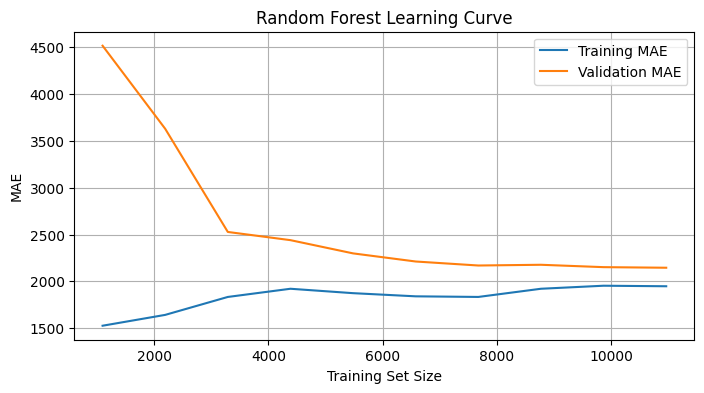

In [74]:
# learn curve for Random Forest to see how performance changes with more training data
from sklearn.model_selection import learning_curve
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

# use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=3)

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(**rf_random_search.best_params_, random_state=42), 
    features_train, 
    target_train, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10))
train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_scores_mean, label='Training MAE')
plt.plot(train_sizes, test_scores_mean, label='Validation MAE')
plt.xlabel('Training Set Size')
plt.ylabel('MAE')
plt.title('Random Forest Learning Curve')
plt.legend()
plt.grid()
plt.show()

the large gap (training MAE ~1000 vs validation MAE ~3000) confirms overfitting.

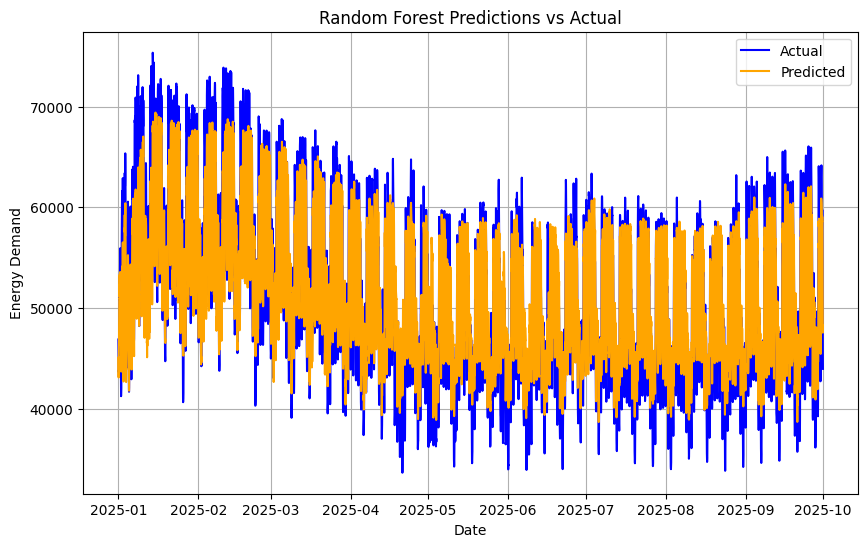

In [75]:
# plot the predictions vs actual values for the best random forest model
plt.figure(figsize=(10, 6)) 
plt.plot(test_data['DateUTC'], target_test, label='Actual', color='blue')
plt.plot(test_data['DateUTC'], rf_tuned_predictions, label='Predicted', color='orange')
plt.xlabel('Date')
plt.ylabel('Energy Demand')
plt.title('Random Forest Predictions vs Actual')  
plt.legend()
plt.grid()  
plt.show()
